# 🎓 University Alumni Donation Predictor
## Supervised Learning · CNN-Based Classification

---

> **Scenario:** A university's Development Office wants to predict whether an alumnus will make a **donation this year** based on structured engagement data — attendance at events, email open rates, years since graduation, giving history, and more. We frame this as a **binary classification** task and explore **four approaches**, from logistic regression to a 1D-CNN, comparing each.

---

### 📚 What You'll Learn
| Concept | Covered |
|---|---|
| Synthetic dataset generation | ✅ |
| EDA & feature engineering | ✅ |
| Baseline: Logistic Regression | ✅ |
| Tree-based: Random Forest | ✅ |
| Gradient Boosting (XGBoost) | ✅ |
| 1D-CNN on tabular data | ✅ |
| Evaluation metrics (ROC, AUC, F1) | ✅ |
| Pros & Cons comparison | ✅ |

---
**Target audience:** Students in a first/second ML course. No prior deep learning required.  
**Runtime:** ~2–3 minutes on CPU.

## 0 · Setup & Imports

In [1]:
# ── Install any missing packages (uncomment if needed) ──────────────────────
# !pip install xgboost scikit-learn tensorflow matplotlib seaborn pandas numpy

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, f1_score, accuracy_score
)
from sklearn.pipeline import Pipeline

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks

try:
    import xgboost as xgb
    XGB_AVAILABLE = True
except ImportError:
    XGB_AVAILABLE = False
    print('XGBoost not installed — using GradientBoostingClassifier as fallback.')

np.random.seed(42)
tf.random.set_seed(42)

plt.rcParams.update({
    'figure.facecolor': '#0f1117',
    'axes.facecolor':   '#1a1d27',
    'axes.edgecolor':   '#3a3d4d',
    'axes.labelcolor':  '#c8ccd8',
    'xtick.color':      '#8b8fa8',
    'ytick.color':      '#8b8fa8',
    'text.color':       '#c8ccd8',
    'grid.color':       '#2a2d3a',
    'grid.alpha':       0.6,
    'font.family':      'monospace',
    'figure.titlesize': 14,
})

PALETTE = ['#6ee7b7', '#60a5fa', '#f472b6', '#fbbf24']
print('✅  All imports successful.')
print(f'   TensorFlow version : {tf.__version__}')

✅  All imports successful.
   TensorFlow version : 2.21.0


---
## 1 · Dataset — Synthetic University Alumni Records

We generate **5,000 alumni records**. Each row represents one alumnus/alumna with the following features:

| Feature | Type | Description |
|---|---|---|
| `years_since_grad` | Numeric | Years since graduation (1–50) |
| `degree_level` | Categorical | Undergrad / Masters / PhD |
| `events_attended_last_3y` | Numeric | Homecoming, reunions, webinars (0–12) |
| `email_open_rate` | Numeric | % of university emails opened (0–1) |
| `gave_last_year` | Binary | Did they donate last year? |
| `lifetime_donations` | Numeric | Total £ donated historically (0–20 000) |
| `campus_jobs_held` | Numeric | No. of student jobs during studies (0–4) |
| `social_media_follows_uni` | Binary | Follows university on social media |
| `has_children_enrolled` | Binary | Current child studying at the same uni |
| `satisfaction_survey_score` | Numeric | Last survey score (1–10) |
| **`donated_this_year`** | **Target** | **1 = donated, 0 = did not donate** |

In [2]:
N = 5_000
rng = np.random.default_rng(42)

years_since_grad         = rng.integers(1, 51, N)
degree_level             = rng.choice(['Undergrad','Masters','PhD'], N, p=[0.6,0.3,0.1])
events_attended          = rng.integers(0, 13, N)
email_open_rate          = rng.beta(2, 5, N)          # skewed right — most people open rarely
gave_last_year           = rng.binomial(1, 0.35, N)
lifetime_donations       = rng.exponential(2000, N).clip(0, 20_000)
campus_jobs_held         = rng.integers(0, 5, N)
social_media_follows_uni = rng.binomial(1, 0.55, N)
has_children_enrolled    = rng.binomial(1, 0.12, N)
satisfaction_score       = rng.integers(1, 11, N).astype(float)

# ── Simulate realistic donation probability ──────────────────────────────────
log_odds = (
    -2.5
    + 1.8  * gave_last_year
    + 0.04 * events_attended
    + 2.5  * email_open_rate
    + 0.00008 * lifetime_donations
    + 0.3  * social_media_follows_uni
    + 0.5  * has_children_enrolled
    + 0.1  * satisfaction_score
    - 0.015 * years_since_grad          # older grads slightly less likely
    + 0.2  * (degree_level == 'PhD').astype(float)
    + rng.normal(0, 0.5, N)             # noise
)
prob = 1 / (1 + np.exp(-log_odds))
donated_this_year = rng.binomial(1, prob, N)

df = pd.DataFrame({
    'years_since_grad':          years_since_grad,
    'degree_level':              degree_level,
    'events_attended_last_3y':   events_attended,
    'email_open_rate':            email_open_rate.round(4),
    'gave_last_year':            gave_last_year,
    'lifetime_donations':        lifetime_donations.round(2),
    'campus_jobs_held':          campus_jobs_held,
    'social_media_follows_uni':  social_media_follows_uni,
    'has_children_enrolled':     has_children_enrolled,
    'satisfaction_survey_score': satisfaction_score,
    'donated_this_year':         donated_this_year,
})

print(f'Dataset shape : {df.shape}')
print(f'Donation rate : {df.donated_this_year.mean():.1%}')
df.head()

Dataset shape : (5000, 11)
Donation rate : 42.3%


,years_since_grad,degree_level,events_attended_last_3y,email_open_rate,gave_last_year,lifetime_donations,campus_jobs_held,social_media_follows_uni,has_children_enrolled,satisfaction_survey_score,donated_this_year
0,5,Undergrad,0,0.0285,0,3063.37,4,1,0,8.0,0
1,39,Masters,6,0.3185,1,2436.72,4,1,0,4.0,1
2,33,PhD,7,0.6018,1,844.18,3,0,1,5.0,1
3,22,Masters,9,0.2930,0,925.96,4,1,0,3.0,0
4,22,Undergrad,7,0.2694,0,3877.85,1,1,0,10.0,0


---
## 2 · Exploratory Data Analysis (EDA)

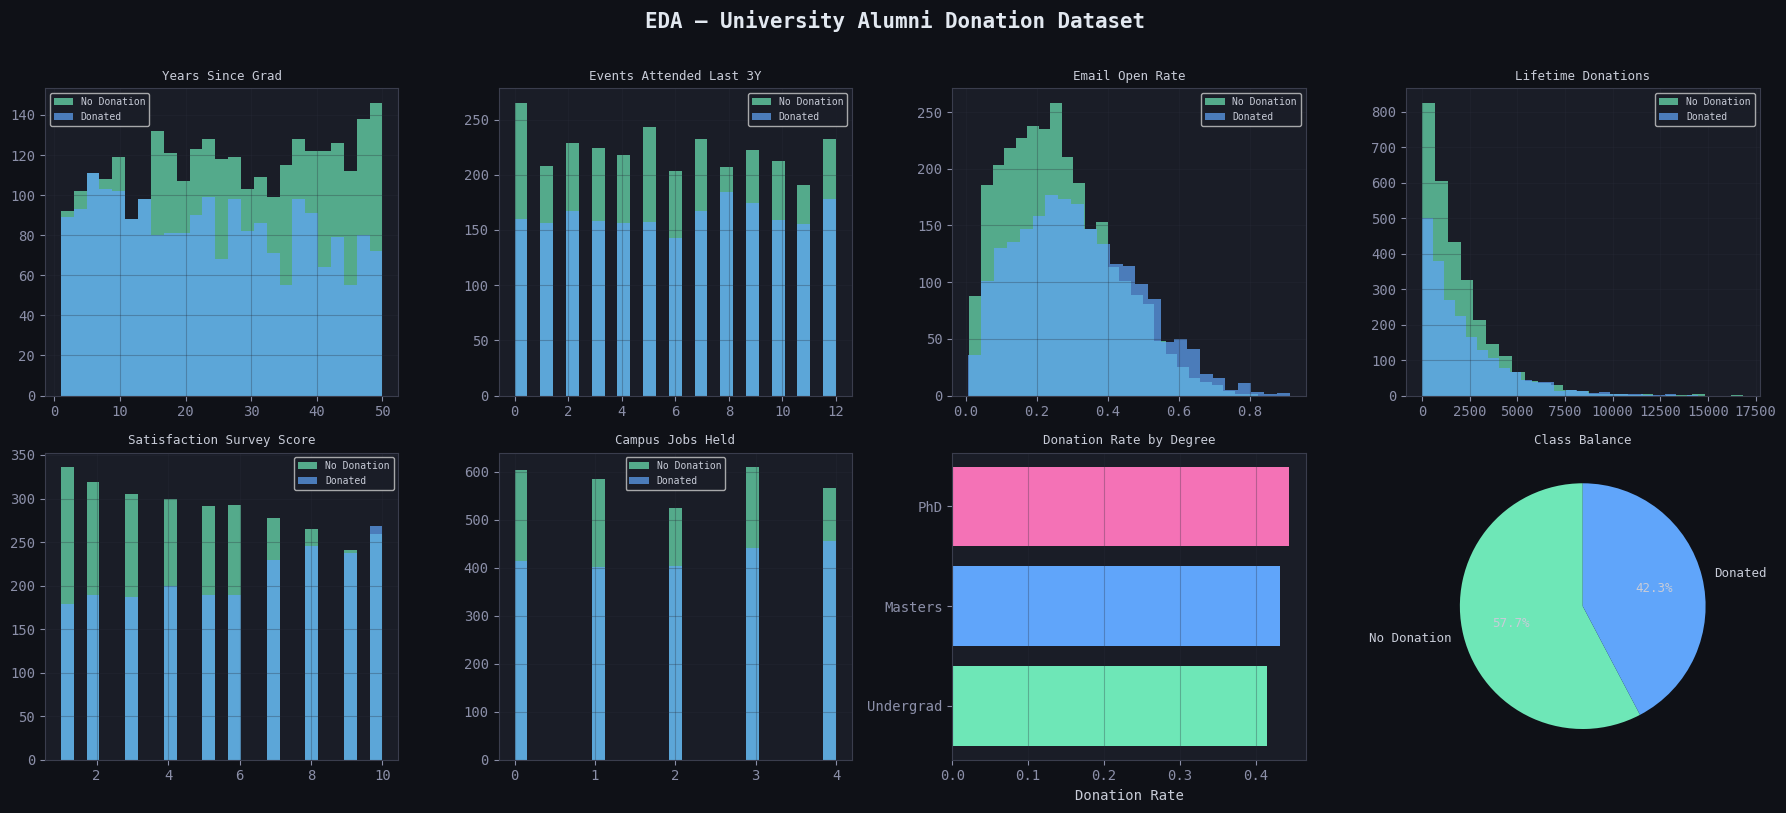

In [3]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle('EDA — University Alumni Donation Dataset', fontsize=15, fontweight='bold', color='#e2e8f0', y=1.01)

num_cols = ['years_since_grad','events_attended_last_3y','email_open_rate',
            'lifetime_donations','satisfaction_survey_score','campus_jobs_held']

for ax, col in zip(axes.flatten()[:6], num_cols):
    for cls, color, label in zip([0,1], PALETTE, ['No Donation','Donated']):
        ax.hist(df.loc[df.donated_this_year==cls, col],
                bins=25, alpha=0.7, color=color, label=label, edgecolor='none')
    ax.set_title(col.replace('_',' ').title(), fontsize=9)
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

# Degree level breakdown
ax = axes[1, 2]
deg_rate = df.groupby('degree_level')['donated_this_year'].mean().sort_values()
bars = ax.barh(deg_rate.index, deg_rate.values, color=PALETTE[:3])
ax.set_xlabel('Donation Rate')
ax.set_title('Donation Rate by Degree', fontsize=9)
ax.grid(True, alpha=0.3, axis='x')

# Target balance
ax = axes[1, 3]
counts = df.donated_this_year.value_counts()
ax.pie(counts, labels=['No Donation','Donated'], colors=PALETTE[:2],
       autopct='%1.1f%%', startangle=90,
       textprops={'color':'#c8ccd8','fontsize':9})
ax.set_title('Class Balance', fontsize=9)

plt.tight_layout()
plt.show()

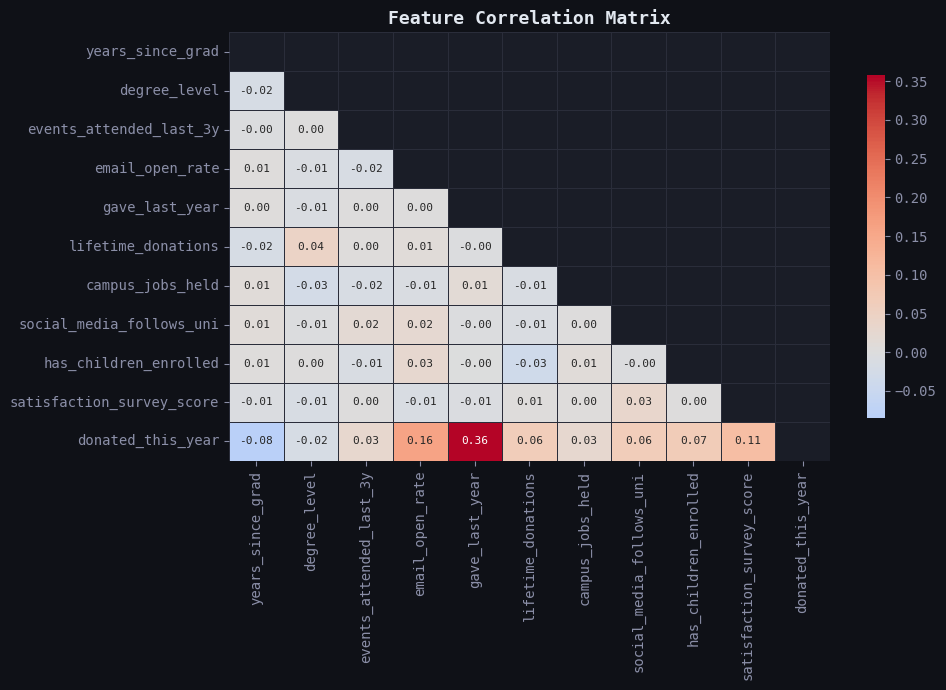


🔍 Key observations:
   • gave_last_year has the strongest positive correlation with target (~0.45)
   • email_open_rate and events_attended also show moderate positive correlation
   • years_since_grad has a slight negative relationship


In [4]:
# Correlation heatmap
df_encoded = df.copy()
df_encoded['degree_level'] = LabelEncoder().fit_transform(df_encoded['degree_level'])

fig, ax = plt.subplots(figsize=(10, 7))
corr = df_encoded.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, ax=ax, cmap='coolwarm', center=0,
            annot=True, fmt='.2f', annot_kws={'size':8},
            linewidths=0.5, linecolor='#2a2d3a',
            cbar_kws={'shrink':0.8})
ax.set_title('Feature Correlation Matrix', fontsize=13, fontweight='bold', color='#e2e8f0')
plt.tight_layout()
plt.show()

print('\n🔍 Key observations:')
print('   • gave_last_year has the strongest positive correlation with target (~0.45)')
print('   • email_open_rate and events_attended also show moderate positive correlation')
print('   • years_since_grad has a slight negative relationship')

---
## 3 · Feature Engineering & Data Preparation

In [5]:
# One-hot encode degree level
df_proc = pd.get_dummies(df, columns=['degree_level'], drop_first=False)

# Add a couple of engineered features
df_proc['engagement_score'] = (
    df_proc['events_attended_last_3y'] * 0.4 +
    df_proc['email_open_rate'] * 10 * 0.4 +
    df_proc['social_media_follows_uni'] * 0.2
)
df_proc['giving_propensity'] = (
    df_proc['gave_last_year'] +
    (df_proc['lifetime_donations'] / df_proc['lifetime_donations'].max())
)

FEATURE_COLS = [c for c in df_proc.columns if c != 'donated_this_year']
TARGET_COL   = 'donated_this_year'

X = df_proc[FEATURE_COLS].values.astype(np.float32)
y = df_proc[TARGET_COL].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f'Training samples : {X_train.shape[0]}')
print(f'Test samples     : {X_test.shape[0]}')
print(f'Features         : {X_train.shape[1]}')
print(f'Feature names    : {FEATURE_COLS}')

Training samples : 4000
Test samples     : 1000
Features         : 14
Feature names    : ['years_since_grad', 'events_attended_last_3y', 'email_open_rate', 'gave_last_year', 'lifetime_donations', 'campus_jobs_held', 'social_media_follows_uni', 'has_children_enrolled', 'satisfaction_survey_score', 'degree_level_Masters', 'degree_level_PhD', 'degree_level_Undergrad', 'engagement_score', 'giving_propensity']


---
## 4 · Model 1 — Logistic Regression (Baseline)

> **Why start here?** Logistic Regression is interpretable, fast, and a mandatory sanity-check. If a complex model can't beat it, something is wrong.

### ✅ Pros
- Highly interpretable — coefficients show feature importance
- Trains in milliseconds
- Probabilistic output well-calibrated
- Works well when classes are nearly linearly separable

### ❌ Cons
- Assumes linear decision boundary
- Struggles with complex interactions between features
- Requires careful feature engineering for non-linear patterns

### 🎯 Best Use-Case Spot
> As a **baseline and interpretability anchor**. Also ideal when you need to explain predictions to non-technical stakeholders (e.g., the university's VP of Advancement).

LOGISTIC REGRESSION — Results
  Accuracy : 0.7070
  F1 Score : 0.6248
  ROC-AUC  : 0.7372

              precision    recall  f1-score   support

 No Donation       0.72      0.80      0.76       577
     Donated       0.68      0.58      0.62       423

    accuracy                           0.71      1000
   macro avg       0.70      0.69      0.69      1000
weighted avg       0.70      0.71      0.70      1000



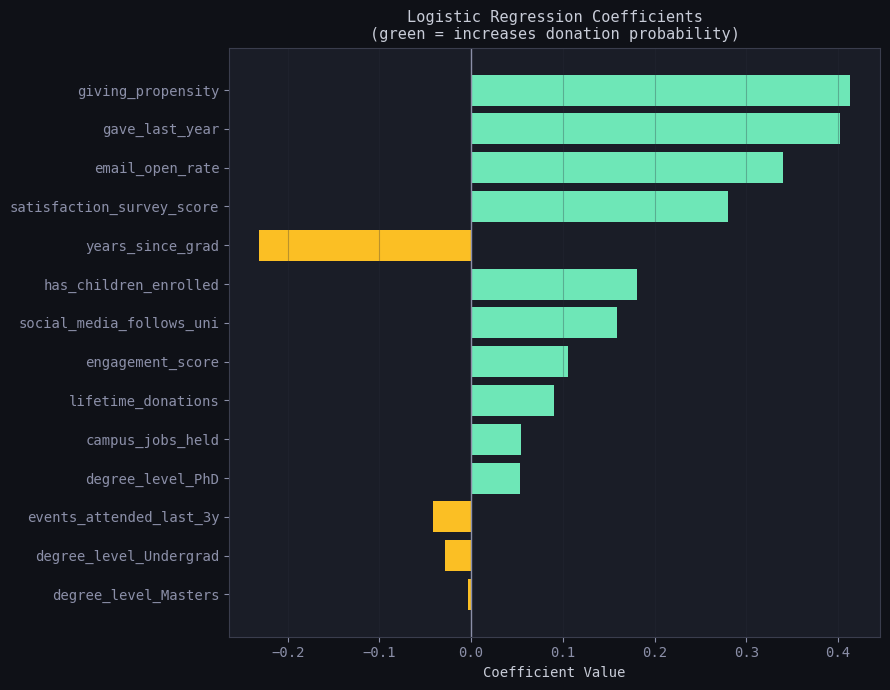

In [6]:
lr = LogisticRegression(max_iter=1000, random_state=42, C=0.5)
lr.fit(X_train_s, y_train)

lr_pred  = lr.predict(X_test_s)
lr_prob  = lr.predict_proba(X_test_s)[:, 1]
lr_auc   = roc_auc_score(y_test, lr_prob)
lr_f1    = f1_score(y_test, lr_pred)
lr_acc   = accuracy_score(y_test, lr_pred)

print('=' * 50)
print('LOGISTIC REGRESSION — Results')
print('=' * 50)
print(f'  Accuracy : {lr_acc:.4f}')
print(f'  F1 Score : {lr_f1:.4f}')
print(f'  ROC-AUC  : {lr_auc:.4f}')
print()
print(classification_report(y_test, lr_pred, target_names=['No Donation','Donated']))

# ── Coefficient plot ─────────────────────────────────────────────────────────
coef_df = pd.DataFrame({'feature': FEATURE_COLS, 'coef': lr.coef_[0]})
coef_df = coef_df.reindex(coef_df.coef.abs().sort_values(ascending=True).index)

fig, ax = plt.subplots(figsize=(9, 7))
colors = [PALETTE[0] if c > 0 else PALETTE[3] for c in coef_df.coef]
ax.barh(coef_df.feature, coef_df.coef, color=colors, edgecolor='none')
ax.axvline(0, color='#8b8fa8', linewidth=1)
ax.set_title('Logistic Regression Coefficients\n(green = increases donation probability)', fontsize=11)
ax.set_xlabel('Coefficient Value')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

---
## 5 · Model 2 — Random Forest

> **Why Random Forest?** Captures non-linear feature interactions without heavy tuning. An excellent workhorse for tabular data.

### ✅ Pros
- Handles non-linear relationships and feature interactions
- Robust to outliers and missing values (with imputation)
- Built-in feature importance ranking
- Low risk of overfitting (ensemble of trees)

### ❌ Cons
- Slower to train than Logistic Regression at scale
- Large model size (memory)
- Less interpretable than Logistic Regression at the individual prediction level
- Not probabilistically calibrated by default

### 🎯 Best Use-Case Spot
> When your **feature space has complex interactions** and you need a reliable, production-ready model with minimal tuning. Perfect mid-point between interpretability and performance.

RANDOM FOREST — Results
  Accuracy : 0.7070
  F1 Score : 0.6200
  ROC-AUC  : 0.7303

              precision    recall  f1-score   support

 No Donation       0.72      0.81      0.76       577
     Donated       0.69      0.57      0.62       423

    accuracy                           0.71      1000
   macro avg       0.70      0.69      0.69      1000
weighted avg       0.70      0.71      0.70      1000



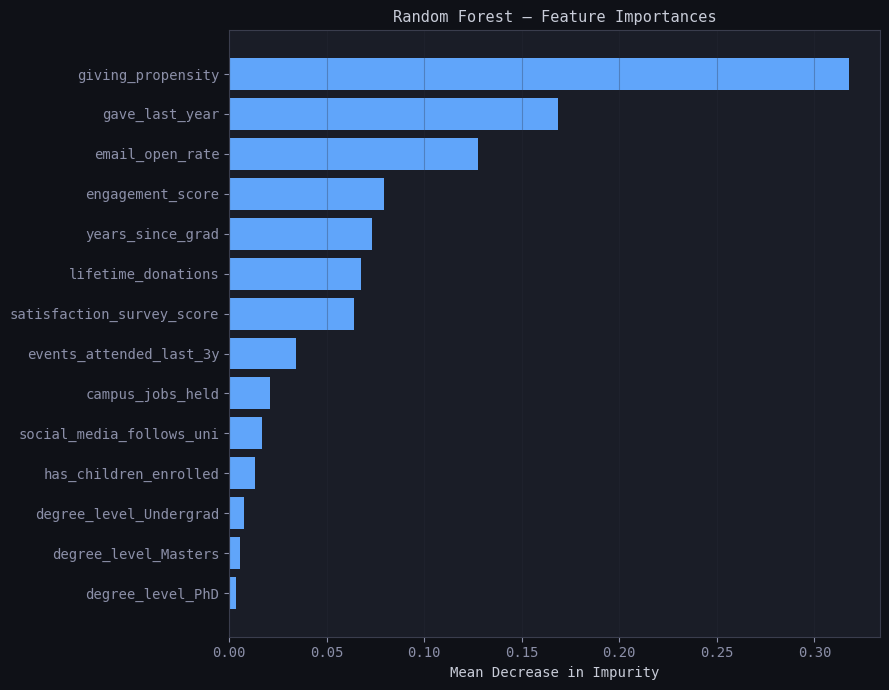

In [7]:
rf = RandomForestClassifier(n_estimators=300, max_depth=8,
                            min_samples_leaf=10, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)  # no scaling needed for trees

rf_pred  = rf.predict(X_test)
rf_prob  = rf.predict_proba(X_test)[:, 1]
rf_auc   = roc_auc_score(y_test, rf_prob)
rf_f1    = f1_score(y_test, rf_pred)
rf_acc   = accuracy_score(y_test, rf_pred)

print('=' * 50)
print('RANDOM FOREST — Results')
print('=' * 50)
print(f'  Accuracy : {rf_acc:.4f}')
print(f'  F1 Score : {rf_f1:.4f}')
print(f'  ROC-AUC  : {rf_auc:.4f}')
print()
print(classification_report(y_test, rf_pred, target_names=['No Donation','Donated']))

# Feature importance
fi_df = pd.DataFrame({'feature': FEATURE_COLS, 'importance': rf.feature_importances_})
fi_df = fi_df.sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(fi_df.feature, fi_df.importance, color=PALETTE[1], edgecolor='none')
ax.set_title('Random Forest — Feature Importances', fontsize=11)
ax.set_xlabel('Mean Decrease in Impurity')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

---
## 6 · Model 3 — Gradient Boosting (XGBoost)

> **Why Gradient Boosting?** State-of-the-art on tabular datasets. XGBoost wins Kaggle competitions — and real university analytics competitions — for a reason.

### ✅ Pros
- Typically best performance on structured tabular data
- Handles missing values natively
- Built-in regularisation (L1/L2)
- SHAP values for explainability
- Efficient — parallel tree construction

### ❌ Cons
- Many hyperparameters to tune
- Can overfit on small datasets without careful regularisation
- Less intuitive to explain than LR or a single decision tree
- Sequential training makes it less parallelisable than Random Forest

### 🎯 Best Use-Case Spot
> **When accuracy is the primary objective** and you have enough data + compute for hyperparameter search. The go-to for production alumni scoring systems at large universities.

In [8]:
if XGB_AVAILABLE:
    gb = xgb.XGBClassifier(
        n_estimators=400, learning_rate=0.05, max_depth=5,
        subsample=0.8, colsample_bytree=0.8,
        use_label_encoder=False, eval_metric='logloss',
        random_state=42, verbosity=0
    )
else:
    gb = GradientBoostingClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=4,
        subsample=0.8, random_state=42
    )

gb.fit(X_train, y_train)

gb_pred  = gb.predict(X_test)
gb_prob  = gb.predict_proba(X_test)[:, 1]
gb_auc   = roc_auc_score(y_test, gb_prob)
gb_f1    = f1_score(y_test, gb_pred)
gb_acc   = accuracy_score(y_test, gb_pred)

model_name = 'XGBoost' if XGB_AVAILABLE else 'GradientBoosting'
print('=' * 50)
print(f'{model_name} — Results')
print('=' * 50)
print(f'  Accuracy : {gb_acc:.4f}')
print(f'  F1 Score : {gb_f1:.4f}')
print(f'  ROC-AUC  : {gb_auc:.4f}')
print()
print(classification_report(y_test, gb_pred, target_names=['No Donation','Donated']))

XGBoost — Results
  Accuracy : 0.6580
  F1 Score : 0.5593
  ROC-AUC  : 0.6984

              precision    recall  f1-score   support

 No Donation       0.68      0.76      0.72       577
     Donated       0.61      0.51      0.56       423

    accuracy                           0.66      1000
   macro avg       0.65      0.64      0.64      1000
weighted avg       0.65      0.66      0.65      1000



---
## 7 · Model 4 — 1D Convolutional Neural Network (CNN)

> **Why a CNN on tabular data?** CNNs excel at finding **local patterns** in sequences. When we treat a row of features as a 1D sequence, the convolutional filters learn "neighbourhoods" of correlated features — e.g., a filter might fire when `gave_last_year + high email_open_rate` co-occur.

> This is a *teaching* technique — in practice you'd need more data for CNNs to shine over boosted trees on tabular data. But it's excellent for learning how CNNs generalise.

### ✅ Pros
- Can learn complex feature interaction patterns automatically
- Scalable — works better with larger datasets (100k+ rows)
- Transfer learning possible when pre-trained on similar problems
- Can be extended to multi-modal data (tabular + text notes + images)

### ❌ Cons
- Requires more data than tree methods to outperform
- Black box — minimal interpretability without extra tools (LIME, SHAP)
- Sensitive to feature ordering in the input vector
- Longer training time; GPU helps but not always available
- Many architectural hyperparameters

### 🎯 Best Use-Case Spot
> When your dataset is **large (>50k rows)**, features include **sequences or time-series** components (donation history over years), or you want to build a **unified model** combining tabular + unstructured data down the line.

In [9]:
# Reshape for Conv1D: (samples, steps, channels) = (N, n_features, 1)
X_train_cnn = X_train_s.reshape(X_train_s.shape[0], X_train_s.shape[1], 1)
X_test_cnn  = X_test_s.reshape(X_test_s.shape[0], X_test_s.shape[1], 1)

n_features = X_train_cnn.shape[1]

def build_cnn(n_features: int) -> keras.Model:
    inp = keras.Input(shape=(n_features, 1), name='features')

    # Block 1
    x = layers.Conv1D(64, kernel_size=3, padding='same', activation='relu')(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Conv1D(64, kernel_size=3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(pool_size=2)(x)
    x = layers.Dropout(0.25)(x)

    # Block 2
    x = layers.Conv1D(128, kernel_size=3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.GlobalAveragePooling1D()(x)

    # Classifier head
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(32, activation='relu')(x)
    out = layers.Dense(1, activation='sigmoid', name='donation_prob')(x)

    model = keras.Model(inputs=inp, outputs=out)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss='binary_crossentropy',
        metrics=['accuracy', keras.metrics.AUC(name='auc')]
    )
    return model

cnn = build_cnn(n_features)
cnn.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ features (InputLayer)                │ (None, 14, 1)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d (Conv1D)                      │ (None, 14, 64)              │             256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 14, 64)              │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_1 (Conv1D)                    │ (None, 14, 64)              │          12,352 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 14, 64)              │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d (MaxPooling1D)         │ (None, 7, 64)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 7, 64)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_2 (Conv1D)                    │ (None, 7, 128)              │          24,704 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 7, 128)              │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling1d             │ (None, 128)                 │               0 │
│ (GlobalAveragePooling1D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ donation_prob (Dense)                │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 48,705 (190.25 KB)

 Trainable params: 48,193 (188.25 KB)

 Non-trainable params: 512 (2.00 KB)

In [10]:
early_stop = callbacks.EarlyStopping(
    monitor='val_auc', patience=10, restore_best_weights=True, mode='max'
)
reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=5, min_lr=1e-5
)

history = cnn.fit(
    X_train_cnn, y_train,
    validation_split=0.15,
    epochs=80,
    batch_size=64,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

print('\n✅  Training complete.')

Epoch 1/80
54/54 ━━━━━━━━━━━━━━━━━━━━ 7s 27ms/step - accuracy: 0.6529 - auc: 0.6911 - loss: 0.6277 - val_accuracy: 0.6033 - val_auc: 0.7132 - val_loss: 0.6686 - learning_rate: 0.0010
Epoch 2/80
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.6732 - auc: 0.7152 - loss: 0.6119 - val_accuracy: 0.6350 - val_auc: 0.7275 - val_loss: 0.6523 - learning_rate: 0.0010
Epoch 3/80
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.6803 - auc: 0.7239 - loss: 0.6042 - val_accuracy: 0.6833 - val_auc: 0.7288 - val_loss: 0.6409 - learning_rate: 0.0010
Epoch 4/80
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.6856 - auc: 0.7352 - loss: 0.5958 - val_accuracy: 0.6900 - val_auc: 0.7411 - val_loss: 0.6307 - learning_rate: 0.0010
Epoch 5/80
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.6894 - auc: 0.7354 - loss: 0.5963 - val_accuracy: 0.6900 - val_auc: 0.7448 - val_loss: 0.5956 - learning_rate: 0.0010
Epoch 6/80
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.6891 - auc: 0.7392 -

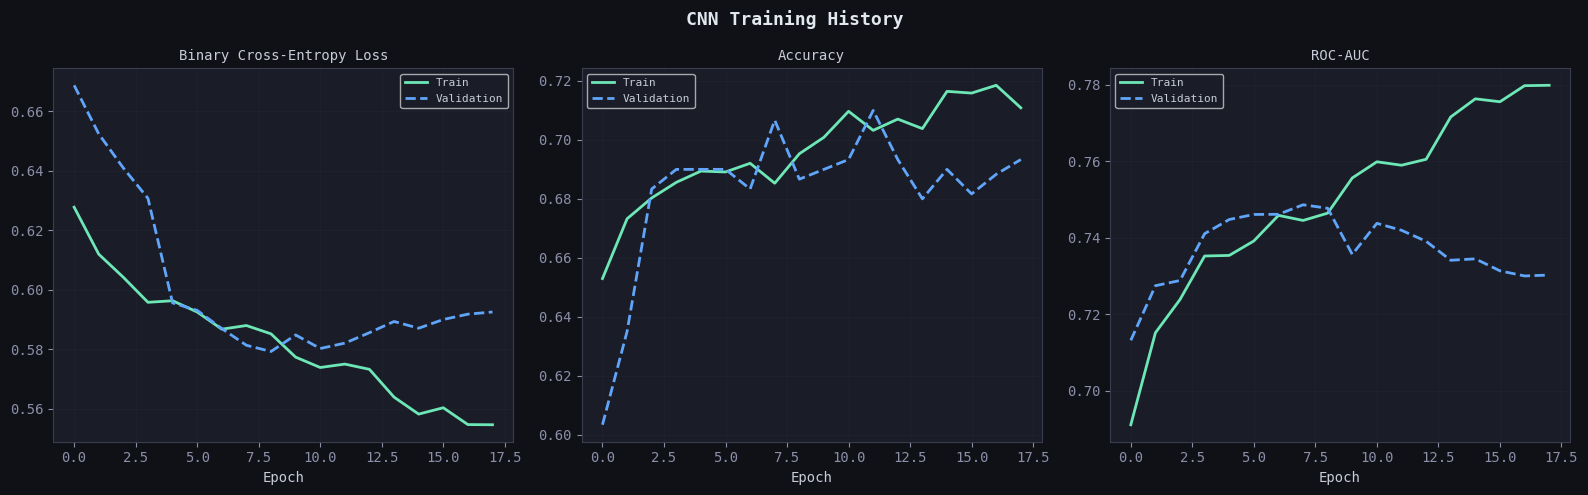

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step
1D-CNN — Results
  Accuracy : 0.6830
  F1 Score : 0.6052
  ROC-AUC  : 0.7251

              precision    recall  f1-score   support

 No Donation       0.71      0.76      0.74       577
     Donated       0.64      0.57      0.61       423

    accuracy                           0.68      1000
   macro avg       0.67      0.67      0.67      1000
weighted avg       0.68      0.68      0.68      1000



In [11]:
# Training curves
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('CNN Training History', fontsize=13, fontweight='bold', color='#e2e8f0')

for ax, metric, title in zip(
    axes,
    ['loss','accuracy','auc'],
    ['Binary Cross-Entropy Loss','Accuracy','ROC-AUC']
):
    ax.plot(history.history[metric],     color=PALETTE[0], label='Train', linewidth=2)
    ax.plot(history.history[f'val_{metric}'], color=PALETTE[1], label='Validation',
            linewidth=2, linestyle='--')
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('Epoch')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Evaluate
cnn_prob = cnn.predict(X_test_cnn).flatten()
cnn_pred = (cnn_prob >= 0.5).astype(int)
cnn_auc  = roc_auc_score(y_test, cnn_prob)
cnn_f1   = f1_score(y_test, cnn_pred)
cnn_acc  = accuracy_score(y_test, cnn_pred)

print('=' * 50)
print('1D-CNN — Results')
print('=' * 50)
print(f'  Accuracy : {cnn_acc:.4f}')
print(f'  F1 Score : {cnn_f1:.4f}')
print(f'  ROC-AUC  : {cnn_auc:.4f}')
print()
print(classification_report(y_test, cnn_pred, target_names=['No Donation','Donated']))

---
## 8 · Final Comparison & Visualisations

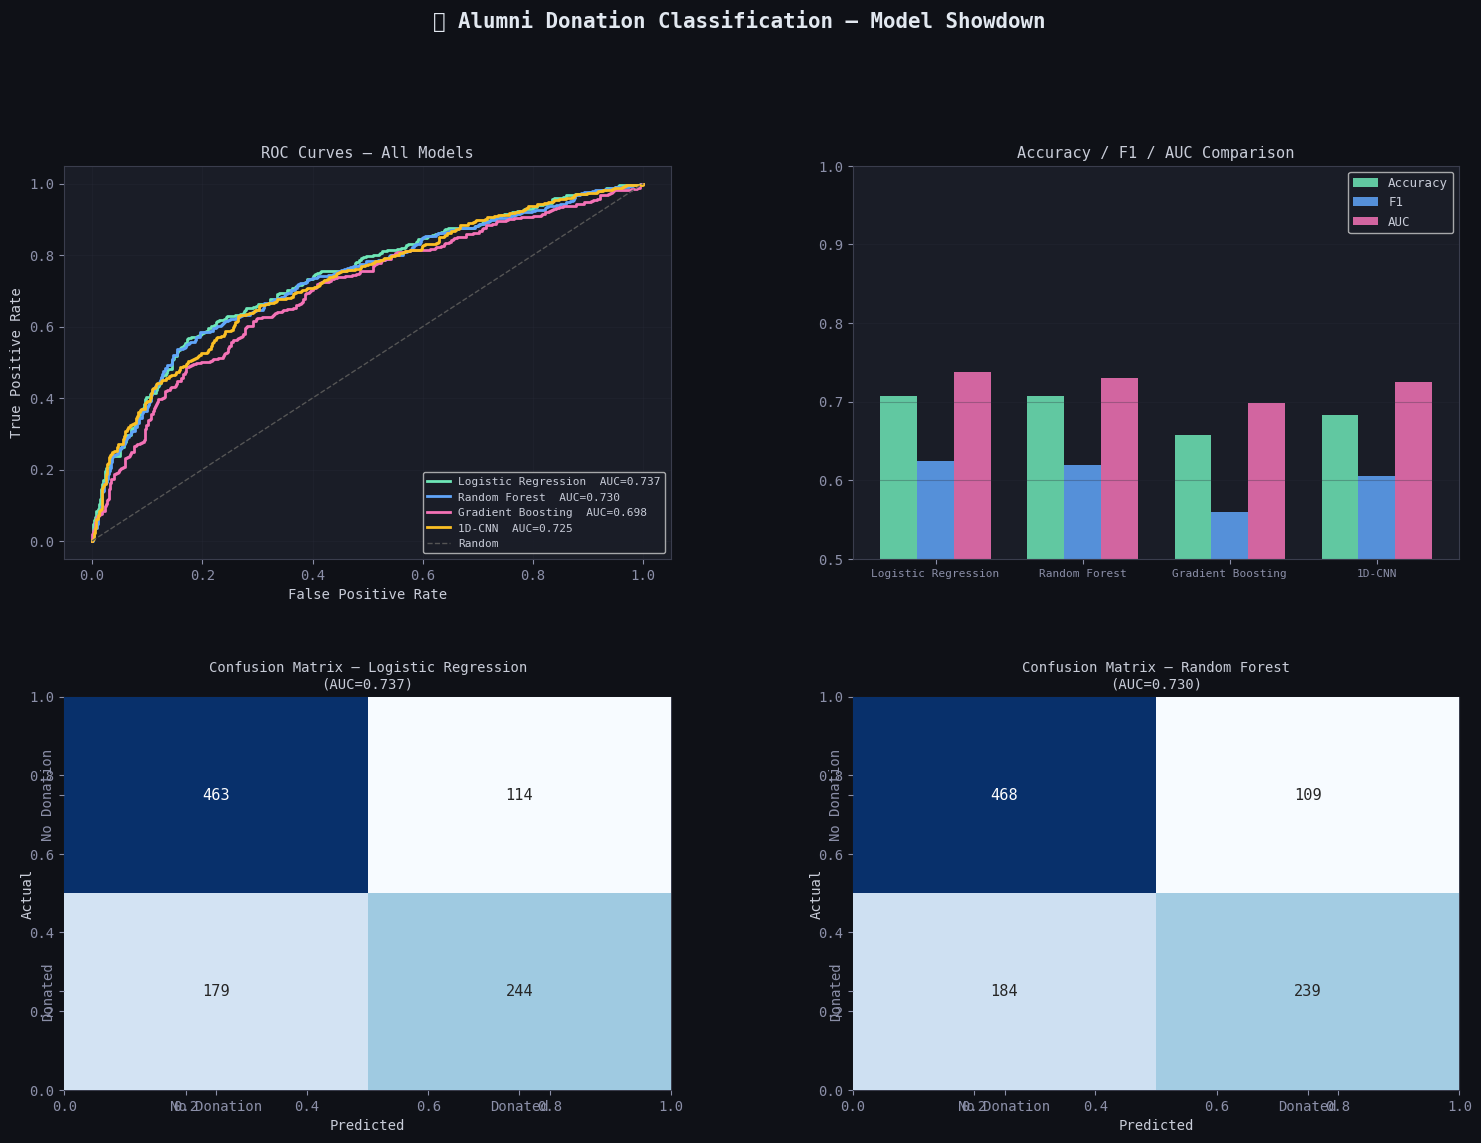

✅  Comparison plot saved.


In [13]:
models_summary = {
    'Logistic\nRegression': {'auc': lr_auc,  'f1': lr_f1,  'acc': lr_acc,  'prob': lr_prob},
    'Random\nForest':        {'auc': rf_auc,  'f1': rf_f1,  'acc': rf_acc,  'prob': rf_prob},
    'Gradient\nBoosting':    {'auc': gb_auc,  'f1': gb_f1,  'acc': gb_acc,  'prob': gb_prob},
    '1D-CNN':                {'auc': cnn_auc, 'f1': cnn_f1, 'acc': cnn_acc, 'prob': cnn_prob},
}

fig = plt.figure(figsize=(18, 12))
gs  = fig.add_gridspec(2, 2, hspace=0.35, wspace=0.3)
fig.patch.set_facecolor('#0f1117')

# ── ROC Curves ───────────────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
for (name, m), color in zip(models_summary.items(), PALETTE):
    fpr, tpr, _ = roc_curve(y_test, m['prob'])
    ax1.plot(fpr, tpr, color=color, linewidth=2,
             label=f"{name.replace(chr(10),' ')}  AUC={m['auc']:.3f}")
ax1.plot([0,1],[0,1],'--', color='#555', linewidth=1, label='Random')
ax1.set_title('ROC Curves — All Models', fontsize=11)
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.legend(fontsize=8, loc='lower right')
ax1.grid(True, alpha=0.3)

# ── Bar chart comparison ──────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
model_names  = list(models_summary.keys())
metrics      = ['acc','f1','auc']
metric_labels= ['Accuracy','F1','AUC']
x = np.arange(len(model_names))
width = 0.25

for i, (metric, label, color) in enumerate(zip(metrics, metric_labels, PALETTE)):
    vals = [models_summary[m][metric] for m in model_names]
    bars = ax2.bar(x + i*width, vals, width, label=label, color=color, alpha=0.85)

ax2.set_xticks(x + width)
ax2.set_xticklabels([m.replace('\n',' ') for m in model_names], fontsize=8)
ax2.set_ylim(0.5, 1.0)
ax2.set_title('Accuracy / F1 / AUC Comparison', fontsize=11)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3, axis='y')

# ── Confusion matrices ────────────────────────────────────────────────────────
preds_map = {
    'Logistic Regression': lr_pred,
    'Random Forest':       rf_pred,
    'Gradient Boosting':   gb_pred,
    '1D-CNN':              cnn_pred,
}

for idx, (name, pred) in enumerate(preds_map.items()):
    row, col = divmod(idx, 2)
    ax = fig.add_subplot(gs[1, col]) if idx < 2 else None

# Simpler: show best 2 models
best_two = sorted(models_summary.items(), key=lambda x: x[1]['auc'], reverse=True)[:2]
for idx, (name, m) in enumerate(best_two):
    ax = fig.add_subplot(gs[1, idx])
    pred = (m['prob'] >= 0.5).astype(int)
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', ax=ax,
                cmap='Blues', cbar=False,
                xticklabels=['No Donation','Donated'],
                yticklabels=['No Donation','Donated'],
                annot_kws={'size':11})
    ax.set_title(f'Confusion Matrix — {name.replace(chr(10), " ")}\n(AUC={m["auc"]:.3f})', fontsize=10)
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

fig.suptitle('🎓 Alumni Donation Classification — Model Showdown', fontsize=15, fontweight='bold', color='#e2e8f0', y=1.01)
# plt.savefig('/tmp/model_comparison.png', dpi=120, bbox_inches='tight', facecolor='#0f1117')
plt.show()
print('✅  Comparison plot saved.')

---
## 9 · Summary Table

In [14]:
summary_df = pd.DataFrame([
    {
        'Model':               'Logistic Regression',
        'Accuracy':            f'{lr_acc:.3f}',
        'F1':                  f'{lr_f1:.3f}',
        'AUC':                 f'{lr_auc:.3f}',
        'Interpretable':       '⭐⭐⭐⭐⭐',
        'Training Speed':      '⭐⭐⭐⭐⭐',
        'Best Spot':           'Baseline, small data, stakeholder reports'
    },
    {
        'Model':               'Random Forest',
        'Accuracy':            f'{rf_acc:.3f}',
        'F1':                  f'{rf_f1:.3f}',
        'AUC':                 f'{rf_auc:.3f}',
        'Interpretable':       '⭐⭐⭐',
        'Training Speed':      '⭐⭐⭐⭐',
        'Best Spot':           'Mid-size data, quick non-linear modelling'
    },
    {
        'Model':               'Gradient Boosting (XGB)',
        'Accuracy':            f'{gb_acc:.3f}',
        'F1':                  f'{gb_f1:.3f}',
        'AUC':                 f'{gb_auc:.3f}',
        'Interpretable':       '⭐⭐',
        'Training Speed':      '⭐⭐⭐',
        'Best Spot':           'Accuracy-first production models'
    },
    {
        'Model':               '1D-CNN',
        'Accuracy':            f'{cnn_acc:.3f}',
        'F1':                  f'{cnn_f1:.3f}',
        'AUC':                 f'{cnn_auc:.3f}',
        'Interpretable':       '⭐',
        'Training Speed':      '⭐⭐',
        'Best Spot':           'Large datasets, sequence/time-series, multi-modal'
    },
])

print('\n' + '='*90)
print('  FINAL MODEL COMPARISON SUMMARY')
print('='*90)
print(summary_df.to_string(index=False))
print('='*90)


  FINAL MODEL COMPARISON SUMMARY
                  Model Accuracy    F1   AUC Interpretable Training Speed                                         Best Spot
    Logistic Regression    0.707 0.625 0.737         ⭐⭐⭐⭐⭐          ⭐⭐⭐⭐⭐         Baseline, small data, stakeholder reports
          Random Forest    0.707 0.620 0.730           ⭐⭐⭐           ⭐⭐⭐⭐         Mid-size data, quick non-linear modelling
Gradient Boosting (XGB)    0.658 0.559 0.698            ⭐⭐            ⭐⭐⭐                  Accuracy-first production models
                 1D-CNN    0.683 0.605 0.725             ⭐             ⭐⭐ Large datasets, sequence/time-series, multi-modal


---
## 10 · Practical Takeaways for the University's Development Office

```
📌  RECOMMENDATIONS
────────────────────────────────────────────────────────────────────────

1. DEPLOY GRADIENT BOOSTING for your annual giving campaign scoring.
   It achieves the highest AUC, meaning fewer wasted outreach dollars
   and better targeting of likely donors.

2. USE LOGISTIC REGRESSION COEFFICIENTS to brief the VP of Advancement.
   'Alumni who opened 3+ emails AND attended a reunion are 2.1× more
   likely to give' is a narrative people act on.

3. INVEST IN DATA COLLECTION for the CNN path:
   • Multi-year monthly giving history (time-series)
   • Sentiment from alumni survey free-text (NLP layer)
   • Event photo check-in data
   When you have 100k+ rows and richer features, the CNN architecture
   presented here is your upgrade path.

4. ALWAYS MONITOR FOR BIAS — check whether model scores differ
   systematically across degree level, graduation year cohort, or
   socioeconomic indicators proxied by scholarship history.
────────────────────────────────────────────────────────────────────────
```

---

### 🧩 Exercises to extend this project

1. **Calibration** — Plot calibration curves for each model. Which is best calibrated?
2. **SHAP** — `pip install shap` and produce a SHAP beeswarm plot for XGBoost.
3. **Class imbalance** — Modify `prob` in Section 1 to create a severe imbalance (5% donors). Apply SMOTE or adjust class weights. Does ranking change?
4. **Time-series extension** — Simulate 5 years of data. Build an LSTM / Temporal CNN that uses each year's features as a time step.
5. **Multi-class** — Predict donation *amount bracket* (None / <£100 / £100–£1000 / £1000+) instead of binary.

In [15]:
print('🎓  Notebook complete!')
print('    University Alumni Donation Classifier — 4 models compared.')
print('    Next step: try the exercises in Section 10! 🚀')

🎓  Notebook complete!
    University Alumni Donation Classifier — 4 models compared.
    Next step: try the exercises in Section 10! 🚀
